# Run your first kernel

Write one line of math, compile it once, and run it unchanged on the
CPU or a GPU.

**Time:** ~5 min · **Runs on:** CPU, GPU switch · **You need:** NumPy
(and CuPy, only if you have a GPU)

A kernel is a plain Python function decorated `@hawk.kernel`: each
parameter's type annotation says what role it plays for every sample.

In [1]:
import hawk
from hawk import Mutable, Param, Scalar


@hawk.kernel
def scale(x: Scalar,              # a per-sample input
          a: Param, b: Param,     # a shared constant: one value for the run
          y: Mutable[Scalar]):    # an output plane the body assigns
    y = a * x + b


scale

<Kernel scale slots=4>

`hawk.artifact.build` compiles it for a chosen target — `"host"` means
the CPU alone, no GPU or `eagle` involved:

In [2]:
import pathlib
import tempfile

import hawk.artifact

work_dir = pathlib.Path(tempfile.mkdtemp())
hawk.artifact.build(scale, work_dir, targets=("host",));

`hawk.load` loads the compiled artifact and `hawk.run` runs it directly:

In [3]:
import numpy as np

host_kernel = hawk.load(work_dir, "scale")
x = np.linspace(0.0, 7.0, 8)
y = np.zeros(8)
hawk.run(host_kernel, x=x, a=2.0, b=1.0, y=y)
y

array([ 1.,  3.,  5.,  7.,  9., 11., 13., 15.])

That is the whole authoring surface for this kernel: declare the planes,
write the arithmetic, `build` it, `load`/`run` it — no eagle and no GPU
anywhere above.

## The same kernel, wherever the data lives

`eagle.deploy(scale)` builds the *same* kernel for host and GPU through
hawk's cache (a rerun compiles nothing) and returns a **plan** — a small
object that knows how to run this kernel on whatever array you hand it,
NumPy or CuPy. The hidden cell below picks a GPU automatically when one
is visible, and falls back to the CPU path otherwise — every tutorial in
this family runs on CPU.

In [4]:
import sys, pathlib as _pathlib
sys.path.insert(0, str(_pathlib.Path.cwd().parent / "_shared"))
from nb_helpers import DEVICE, plot_style, to_numpy, xp
plot_style()

In [5]:
import eagle

plan = eagle.deploy(scale, cache_dir=work_dir)
y_xp = plan.run(x=xp.asarray(x), a=2.0, b=1.0)
agrees = np.allclose(to_numpy(y_xp), y)
print("DEVICE:", DEVICE, "| y matches the CPU run:", agrees)

DEVICE: cpu | y matches the CPU run: True


Same `x`, run on the host above and through `eagle.deploy` here — the
numbers agree. One plot makes it visible:

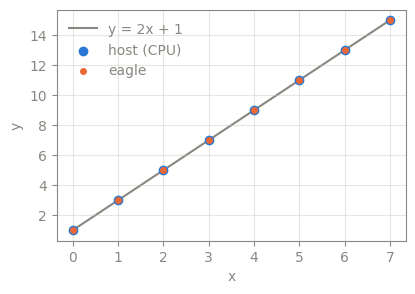

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.plot(x, y, color="#898781", lw=1.5, zorder=1, label="y = 2x + 1")
ax.scatter(x, y, color="#2a78d6", s=36, zorder=2, label="host (CPU)")
ax.scatter(x, to_numpy(y_xp), color="#eb6834", s=16, zorder=3, label="eagle")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(frameon=False)
ax.grid(alpha=0.4)
plt.show()

## What just happened

- A kernel's parameter annotations declare its planes (`Scalar`, `Param`,
  `Mutable[...]`); the body is ordinary arithmetic over them.
- `hawk.artifact.build` + `hawk.load`/`hawk.run` compile and run a kernel on the
  **host alone**, with no eagle, no GPU, and no manifest involved.
- `eagle.deploy(kernel)` builds the same kernel for every target once and
  runs it wherever its *data* lives — a NumPy array on the CPU, a CuPy
  array on the GPU — so one plan serves both without a second code path.

## Try this

In the `build`/`run` cells above, change `b=1.0` to `b=0.0` and re-run
all three cells: the line now passes through the origin, and nothing
else about the kernel changes.

## Next

[Arguments and shapes](02_arguments_and_shapes) — pick the right plane
type for a vector, a matrix, or a quaternion, and see how a batch of
samples is laid out in memory. *Deeper:* [Interoperability](../interop) for
every detail of how a plane binds to a NumPy/CuPy/Torch array.